In [1]:
import sys, os, logging, gc
import numpy as np
from scipy import optimize

from astropy.cosmology import Planck18
import py21cmfast as p21c
from py21cmfast import cache_tools

is_josh = False
if is_josh:

    os.environ['DM21CM_DIR'] = '/global/scratch/projects/pc_heptheory/fosterjw/21CM_Project/DM21cm/'
    os.environ['DM21CM_DATA_DIR'] =  '/global/scratch/projects/pc_heptheory/fosterjw/21CM_Project/Data01/'

    os.environ['DH_DIR'] = '/global/scratch/projects/pc_heptheory/fosterjw/21CM_Project/DarkHistory/'
    os.environ['DH_DATA_DIR'] = '/global/scratch/projects/pc_heptheory/fosterjw/21CM_Project/DarkHistory/DHData/'

    os.environ['P21C_CACHE_DIR'] = './TestCache/'
    
import numpy as np
from scipy import interpolate
from astropy.cosmology import Planck18
import astropy.units as u

from jax import config
config.update("jax_enable_x64", True)
import jax.numpy as jnp

import py21cmfast as p21c
from py21cmfast import cache_tools

sys.path.append(os.environ['DH_DIR'])
from darkhistory.spec.spectrum import Spectrum

sys.path.append(os.environ['DM21CM_DIR'])
import dm21cm.physics as phys
from dm21cm.dh_wrappers import DarkHistoryWrapper, TransferFunctionWrapper
from dm21cm.utils import load_h5_dict
from dm21cm.data_cacher import Cacher
from dm21cm.profiler import Profiler

logging.getLogger().setLevel(logging.INFO)
logging.getLogger('21cmFAST').setLevel(logging.CRITICAL+1)
logging.getLogger('py21cmfast._utils').setLevel(logging.CRITICAL+1)
logging.getLogger('py21cmfast.wrapper').setLevel(logging.CRITICAL+1)

#######################################
###   Import and Construct DM21cm   ###
#######################################

cache_dir = os.environ['P21C_CACHE_DIR']

os.environ['P21C_CACHE_DIR'] = cache_dir
p21c.config['direc'] = os.environ['P21C_CACHE_DIR']
WDIR = os.environ['DM21CM_DIR']
sys.path.append(WDIR)
from dm21cm.dm_params import DMParams
#from dm21cm.evolve import evolve

use_tqdm = True

/n/home07/yitians/.conda/envs/dm21cm/lib/python3.11/site-packages/py21cmfast/_cfg.py:58: UserWarning: Your configuration file is out of date. Updating...
  warnings.warn(
/n/home07/yitians/.conda/envs/dm21cm/lib/python3.11/site-packages/py21cmfast/_cfg.py:42: UserWarning: Your configuration file is out of date. Updating...
  warnings.warn("Your configuration file is out of date. Updating...")


In [2]:
from dm21cm.evolve import get_z_edges, split_xray, gen_injection_boxes, get_r_shells

In [3]:
run_name = 'test_bath_in_step'
z_start = 45.
z_end = 5.
dm_params = DMParams(
    mode='decay',
    primary='phot_delta',
    m_DM=3e3, # [eV]
    lifetime=1e26, # [s]
)
enable_elec = False

p21c_initial_conditions = p21c.initial_conditions(
    user_params = p21c.UserParams(
        HII_DIM = 32,
        BOX_LEN = 32*2, # [conformal Mpc]
        N_THREADS = 32,
    ),
    cosmo_params = p21c.CosmoParams(
        OMm = Planck18.Om0,
        OMb = Planck18.Ob0,
        POWER_INDEX = Planck18.meta['n'],
        #SIGMA_8 = Planck18.meta['sigma8'],
        SIGMA_8 = 1e-6,
        hlittle = Planck18.h,
    ),
    random_seed = 54321,
    write = True,
)
# p21c_astro_params = p21c.AstroParams._defaults_
# astro_params = p21c_astro_params
astro_params = None
p21c_astro_params = None
clear_cache = True
use_DH_init = True
no_injection = False
tf_on_device = True
rerun_DH = False
use_xray_interp_shell = True

/n/home07/yitians/.conda/envs/dm21cm/lib/python3.11/site-packages/py21cmfast/inputs.py:487: UserWarning: The USE_INTERPOLATION_TABLES setting has changed in v3.1.2 to be default True. You can likely ignore this warning, but if you relied onhaving USE_INTERPOLATION_TABLES=False by *default*, please set it explicitly. To silence this warning, set it explicitly to True. Thiswarning will be removed in v4.
  warnings.warn(


In [4]:
def p21c_step(perturbed_field, spin_temp, ionized_box,
             input_heating=None, input_ionization=None, input_jalpha=None, astro_params=astro_params):

    spin_temp = p21c.spin_temperature(
        perturbed_field = perturbed_field,
        previous_spin_temp = spin_temp,
        input_heating_box = input_heating,
        input_ionization_box = input_ionization,
        input_jalpha_box = input_jalpha,
        astro_params = astro_params,
    )

    ionized_box = p21c.ionize_box(
        perturbed_field = perturbed_field,
        previous_ionize_box = ionized_box,
        spin_temp = spin_temp,
        astro_params = astro_params,
    )

    brightness_temp = p21c.brightness_temperature(
        ionized_box = ionized_box,
        perturbed_field = perturbed_field,
        spin_temp = spin_temp,
    )

    return spin_temp, ionized_box, brightness_temp

In [5]:
if is_josh:
    data_dir = os.environ['DM21CM_DATA_DIR']
else:
    data_dir = os.environ['DM21CM_DATA_DIR'] + '/tf/zf01/data'
cache_dir = os.environ['P21C_CACHE_DIR'] + '/' + run_name
p21c.config['direc'] = cache_dir
logging.info(f"Cache dir: {cache_dir}")
os.makedirs(cache_dir, exist_ok=True)
if clear_cache:
    cache_tools.clear_cache()
gc.collect()

#===== initialize =====
#--- physics parameters ---
abscs = load_h5_dict(f"{data_dir}/abscissas.h5")
dm_params.set_inj_specs(abscs)

EPSILON = 1e-6
p21c.global_params.Z_HEAT_MAX = z_start + EPSILON
p21c.global_params.ZPRIME_STEP_FACTOR = abscs['zplusone_step_factor']

box_dim = p21c_initial_conditions.user_params.HII_DIM
box_len = p21c_initial_conditions.user_params.BOX_LEN
cosmo = Planck18

#--- DarkHistory and transfer functions ---
tf_wrapper = TransferFunctionWrapper(
    box_dim = box_dim,
    abscs = abscs,
    prefix = data_dir,
    enable_elec = enable_elec,
    on_device = tf_on_device,
)

INFO:root:Cache dir: /n/holyscratch01/iaifi_lab/yitians/21cmFAST-cache/test_bath_in_step


INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': NOT_FOUND: Could not find registered platform with name: "rocm". Available platform names are: Interpreter CUDA
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': module 'jaxlib.xla_extension' has no attribute 'get_tpu_client'
INFO:root:TransferFunctionWrapper: Loaded photon transfer functions.
INFO:root:TransferFunctionWrapper: Skipping electron transfer functions.


In [6]:
#--- xray ---
xray_cacher = Cacher(box_dim=box_dim, dx=box_len/box_dim)

#--- redshift stepping ---
z_edges = get_z_edges(z_start, z_end, p21c.global_params.ZPRIME_STEP_FACTOR)

#===== initial steps =====
dh_wrapper = DarkHistoryWrapper(dm_params, prefix=p21c.config[f'direc'])

# We have to synchronize at the second step because 21cmFAST acts weird in the first step:
# - global_params.TK_at_Z_HEAT_MAX is not set correctly (it is probably set and evolved for a step)
# - global_params.XION_at_Z_HEAT_MAX is not set correctly (it is probably set and evolved for a step)
# - first step ignores any values added to spin_temp.Tk_box and spin_temp.x_e_box
z_match = z_edges[1]
if use_DH_init:
    dh_wrapper.evolve(end_rs=(1+z_match)*0.9, rerun=rerun_DH)
    T_k_DH_init, x_e_DH_init, phot_bath_spec = dh_wrapper.get_init_cond(rs=1+z_match)
else:
    phot_bath_spec = Spectrum(abscs['photE'], np.zeros_like(abscs['photE']), spec_type='N', rs=1+z_match) # [ph / Bavg]

INFO:root:DarkHistoryWrapper: Found existing DarkHistory initial conditions.
INFO:root:DarkHistoryWrapper: Running DarkHistory to generate initial conditions...


****** Loading transfer functions... ******
Using data at /n/holyscratch01/iaifi_lab/yitians/darkhistory/DHdata_v1_1
    for propagating photons...   Done!
    for low-energy photons...  Done!
    for low-energy electrons...  Done!
    for high-energy deposition...  Done!
    for total upscattered CMB energy rate...  Done!
****** Loading complete! ******
****** Loading transfer functions... ******
    for inverse Compton (Thomson)...  Done!
    for inverse Compton (relativistic)...  Done!
    for inverse Compton (energy loss)...  Done!
****** Loading complete! ******
Loading time: 5.866 s


  0%|          | 2/430 [00:00<00:32, 13.15it/s]

Initialization time: 0.047 s


100%|██████████| 430/430 [00:48<00:00,  8.86it/s]
INFO:root:DarkHistoryWrapper: Saved DarkHistory initial conditions.


Main loop time: 48.528 s


In [7]:
perturbed_field = p21c.perturb_field(redshift=z_edges[1], init_boxes=p21c_initial_conditions, write = True)
spin_temp, ionized_box, brightness_temp = p21c_step(perturbed_field=perturbed_field, spin_temp=None, ionized_box=None, astro_params=p21c_astro_params)
if use_DH_init:
    spin_temp.Tk_box += T_k_DH_init - np.mean(spin_temp.Tk_box)
    spin_temp.x_e_box += x_e_DH_init - np.mean(spin_temp.x_e_box)
    ionized_box.xH_box = 1 - spin_temp.x_e_box

#===== main loop =====
z_edges = z_edges[1:] # Maybe fix this later
z_range = range(len(z_edges)-1)
records = []
profiler = Profiler()

#--- trackers ---
i_xray_loop_start = 0 # where we start looking for annuli

## LOOP START

In [8]:
i_z = 0

In [26]:
i_z += 1
print(i_z)

1


In [9]:
print(f'i_z={i_z}/{len(z_edges)-2} z={z_edges[i_z]:.2f}')

#===== physical quantities =====
z_current = z_edges[i_z]
z_next = z_edges[i_z+1]
dt = phys.dt_step(z_current, np.exp(abscs['dlnz']))

#--- for interpolation ---
delta_plus_one_box = 1 + np.asarray(perturbed_field.density)
x_e_box = np.asarray(1 - ionized_box.xH_box)
T_k_box = np.asarray(spin_temp.Tk_box)
tf_wrapper.init_step(rs=1+z_current, delta_plus_one_box=delta_plus_one_box, x_e_box=x_e_box, T_k_box=T_k_box)

#--- for dark matter ---
nBavg = phys.n_B * (1+z_current)**3 # [Bavg / (physical cm)^3]
rho_DM_box = delta_plus_one_box * phys.rho_DM * (1+z_current)**3 # [eV/(physical cm)^3]
inj_per_Bavg_box = phys.inj_rate(rho_DM_box, dm_params) * dt * dm_params.struct_boost(1+z_current) / nBavg # [inj/Bavg]

i_z=0/203 z=44.68


## first step

## otherwise

## force bath

In [28]:
xray_cacher.z_s

array([], dtype=float64)

In [10]:
i_z

0

In [ ]:
for i, state in enumerate(xray_cacher.states):
    print(i, state.spectrum.toteng())

0 9.14348695743958e-13
1 1.3506378038884568e-12
2 6.188322266544179e-11


In [40]:
for i, state in enumerate(xray_cacher.states):
    depion_before = np.mean(tf_wrapper.dep_box[..., 0])
    tf_wrapper.inject_phot(state.spectrum, inject_type='xray', weight_box=jnp.ones((box_dim, box_dim, box_dim)))
    depion = np.mean(tf_wrapper.dep_box[..., 0]) - depion_before
    print(i, state.z_end, depion)

0 44.22620305254949 8.711200017919165e-14
1 43.77841886391038 1.618523189827693e-13
2 43.335068182089486 2.3606382764002543e-11


In [42]:
np.mean(tf_wrapper.dep_box[...,0])

Array(2.38553471e-11, dtype=float64)

## resume here

In [10]:
depion_before = np.mean(tf_wrapper.dep_box[...,0])
print(depion_before)

0.0


In [11]:
#--- bath and homogeneous portion of xray ---
tf_wrapper.inject_phot(phot_bath_spec, inject_type='bath')

#--- dark matter (on-the-spot) ---
tf_wrapper.inject_from_dm(dm_params, inj_per_Bavg_box)

In [13]:
np.mean(tf_wrapper.dep_box[...,0]) - depion_before

Array(0.00049188, dtype=float64)

In [ ]:
#===== 21cmFAST step =====
perturbed_field = p21c.perturb_field(redshift=z_next, init_boxes=p21c_initial_conditions)
input_heating, input_ionization, input_jalpha = gen_injection_boxes(z_next, p21c_initial_conditions)
tf_wrapper.populate_injection_boxes(input_heating, input_ionization, input_jalpha, dt,)
spin_temp, ionized_box, brightness_temp = p21c_step(
    perturbed_field, spin_temp, ionized_box,
    input_heating = input_heating,
    input_ionization = input_ionization,
    input_jalpha = input_jalpha,
    astro_params = p21c_astro_params
)

#===== prepare spectra for next step =====
#--- bath (separating out xray) ---
prop_phot_N = np.array(tf_wrapper.prop_phot_N) # propagating and emitted photons have been stored in tf_wrapper up to this point, time to get them out
emit_phot_N = np.array(tf_wrapper.emit_phot_N)
emit_bath_N, emit_xray_N = split_xray(emit_phot_N, abscs['photE'])
phot_bath_spec = Spectrum(abscs['photE'], prop_phot_N + emit_bath_N, rs=1+z_current, spec_type='N') # photons not emitted to the xray band are added to the bath (treated as uniform)
phot_bath_spec.redshift(1+z_next)

#--- xray ---
x_e_for_attenuation = 1 - np.mean(ionized_box.xH_box)
attenuation_arr = np.array(tf_wrapper.attenuation_arr(rs=1+z_current, x=np.mean(x_e_for_attenuation))) # convert from jax array
xray_cacher.advance_spectra(attenuation_arr, z_next)

xray_spec = Spectrum(abscs['photE'], emit_xray_N, rs=1+z_current, spec_type='N') # [ph/Bavg]
xray_spec.redshift(1+z_next)
xray_tot_eng = xray_spec.toteng()
if xray_tot_eng == 0.:
    xray_rel_eng_box = np.zeros_like(tf_wrapper.xray_eng_box)
else:
    xray_rel_eng_box = tf_wrapper.xray_eng_box / xray_tot_eng # [1 (relative energy)/Bavg]
if not no_injection:
    # TMP: duplicate the first state for interpolation
    # if len(xray_cacher.states) == 0:
    #     xray_cacher.cache(z_current-1, z_current, xray_spec, xray_rel_eng_box)
    xray_cacher.cache(z_current, z_next, xray_spec, xray_rel_eng_box)

#===== calculate and save some quantities =====
dE_inj_per_Bavg = dm_params.eng_per_inj * np.mean(inj_per_Bavg_box) # [eV/Bavg]
dE_inj_per_Bavg_unclustered = dE_inj_per_Bavg / dm_params.struct_boost(1+z_current) # [eV/Bavg]

records.append({
    'z'   : z_next,
    'T_s' : np.mean(spin_temp.Ts_box), # [mK]
    'T_b' : np.mean(brightness_temp.brightness_temp), # [K]
    'T_k' : np.mean(spin_temp.Tk_box), # [K]
    'x_e' : np.mean(spin_temp.x_e_box), # [1]
    '1-x_H' : np.mean(1 - ionized_box.xH_box), # [1]
    'E_phot' : phot_bath_spec.toteng(), # [eV/Bavg]
    'phot_N' : phot_bath_spec.N, # [ph/Bavg]
    'dE_inj_per_B' : dE_inj_per_Bavg, # [eV/Bavg]
    'dE_inj_per_Bavg_unclustered' : dE_inj_per_Bavg_unclustered, # [eV/Bavg]
    'dep_ion'  : np.mean(tf_wrapper.dep_box[...,0] + tf_wrapper.dep_box[...,1]), # [eV/Bavg]
    'dep_exc'  : np.mean(tf_wrapper.dep_box[...,2]), # [eV/Bavg]
    'dep_heat' : np.mean(tf_wrapper.dep_box[...,3]), # [eV/Bavg]
    'x_e_slice' : np.array(spin_temp.x_e_box[0]), # [1]
    'x_H_slice' : np.array(ionized_box.xH_box[0]), # [1]
    'T_k_slice' : np.array(spin_temp.Tk_box[0]), # [K]
})

In [15]:
import matplotlib.pyplot as plt

In [18]:
x_e_for_attenuation = 1 - np.mean(ionized_box.xH_box)
attenuation_arr = np.array(tf_wrapper.attenuation_arr(rs=1+z_current, x=np.mean(x_e_for_attenuation)))

In [ ]:

plt.xscale('log')
plt.xlim

In [17]:
np.searchsorted(abscs['photE'], 1e2)

179

Text(0, 0.5, 'Number of photons in bin * energy of bin')

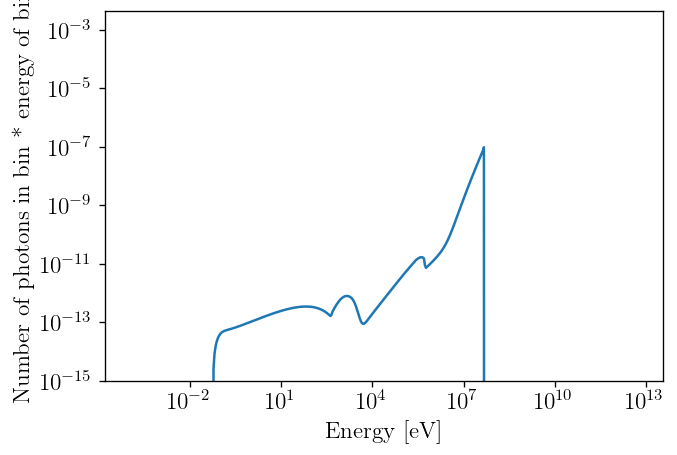

In [23]:
plt.plot(phot_bath_spec.eng, phot_bath_spec.N*phot_bath_spec.eng)
plt.loglog()
plt.ylim(1e-15,None)
plt.xlabel('Energy [eV]')
plt.ylabel('Number of photons in bin * energy of bin')

In [25]:
xray_cacher.states[0].spectrum.N

IndexError: list index out of range

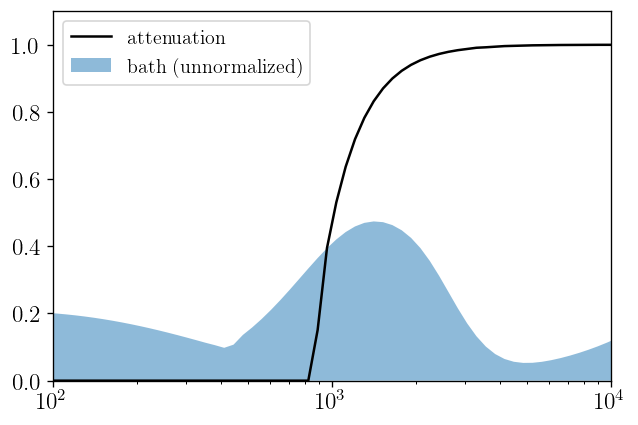

In [24]:
plt.plot(abscs['photE'], attenuation_arr, color='k', label='attenuation')
NE = phot_bath_spec.eng * phot_bath_spec.N
plt.fill_between(phot_bath_spec.eng, NE/NE[179]/5, label='bath (unnormalized)', alpha=0.5)
plt.xscale('log')
plt.xlim(100, 1e4)
plt.ylim(0, 1.1)
plt.legend()

## GO BACK